<class 'numpy.float64'>
0.9989743589743589
KNN classifier accuracy (k=1): 99.90%

Predicted     0    1
Actual              
0          1468    2
1             0  480
<class 'numpy.float64'>
0.9994871794871795
KNN classifier accuracy (k=2): 99.95%

Predicted     0    1
Actual              
0          1469    1
1             0  480
<class 'numpy.float64'>
0.9989743589743589
KNN classifier accuracy (k=3): 99.90%

Predicted     0    1
Actual              
0          1468    2
1             0  480
<class 'numpy.float64'>
0.9989743589743589
KNN classifier accuracy (k=4): 99.90%

Predicted     0    1
Actual              
0          1468    2
1             0  480
<class 'numpy.float64'>
0.9989743589743589
KNN classifier accuracy (k=5): 99.90%

Predicted     0    1
Actual              
0          1468    2
1             0  480
<class 'numpy.float64'>
1.0
KNN classifier accuracy (k=6): 100.00%

Predicted     0    1
Actual              
0          1470    0
1             0  480
<class 'numpy.floa

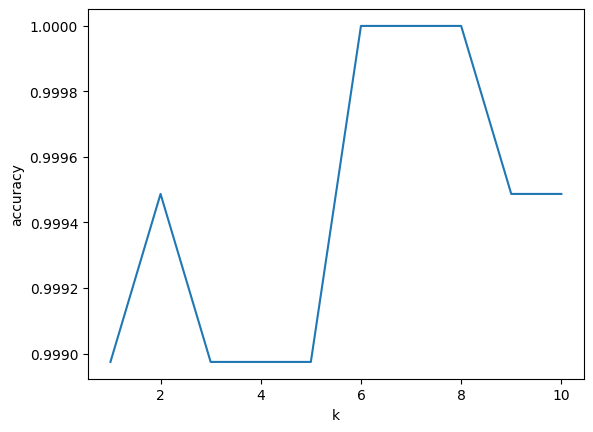

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
Wine = pd.read_csv("/workspaces/Human-vs-ML-Project/data/Wine.csv")
WineFeatures = pd.read_csv("/workspaces/Human-vs-ML-Project/data/Wine_Feature.csv")

X = WineFeatures
Wine["targetData"] = Wine["color"].apply(lambda color: 1 if color == "red" else 0)
y = Wine["targetData"]
# print(y.head(10))
# print(X.head(10))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

accuracy_list = []
kval = []

for i in range(10):
    k = i+1
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    y_train_pred = knn.predict(X_train)

    conf_matrix_knn = pd.crosstab(
        y_test,
        y_pred,
        rownames=['Actual'],
        colnames=['Predicted']
    )

    accuracy_knn = (y_pred == y_test).mean()

    accuracy_list.append(accuracy_knn)
    kval.append(k)

    print(type(accuracy_knn))
    print(accuracy_knn)
    print(f"KNN classifier accuracy (k={k}): {accuracy_knn:.2%}\n")
    print(conf_matrix_knn)

plt.plot(kval, accuracy_list)
plt.xlabel("k")
plt.ylabel("accuracy")
plt.show()